# Laptop sales data cleaning 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

In [3]:
data=pd.read_csv('laptop_sales.csv')

In [23]:
data.head()

,Unnamed: 0,Name,Discounted Price,Actual Price,Rating,Reviews,Brand,Model
0,0.0,Apple MacBook Air 13 M1 MGN63 (8GB-256GB),203499.0,258000.0,5.000000,2.000000,Apple,MacBook Air 13 M1 MGN63
1,1.0,Apple Macbook Air 13 MW123 M4 Chip,281999.0,350000.0,4.300000,5.000000,Apple,Macbook Air 13 MW123 M4 Chip
2,2.0,ASUS Zenbook 14 UX3405CA Intel Core Ultra 7 25...,285999.0,330000.0,4.753846,1.615385,ASUS,Zenbook 14 UX3405CA Intel Core Ultra 7 255H
3,3.0,Lenovo ThinkPad E16 Gen 2 - Intel Core Ultra 7...,287999.0,340000.0,4.753846,1.615385,Lenovo,ThinkPad E16 Gen 2 - Intel Core Ultra 7
4,4.0,Lenovo IdeaPad Slim 3 Ryzen 7 (8GB-512GB),146999.0,175000.0,4.753846,1.615385,Lenovo,IdeaPad Slim 3 Ryzen 7


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        306 non-null    float64
 1   Name              306 non-null    object 
 2   Discounted Price  306 non-null    float64
 3   Actual Price      306 non-null    float64
 4   Rating            306 non-null    float64
 5   Reviews           306 non-null    float64
 6   Brand             306 non-null    object 
 7   Model             306 non-null    object 
dtypes: float64(5), object(3)
memory usage: 19.3+ KB


In [19]:
data.isnull().sum()

Unnamed: 0            0
Name                  0
Discounted Price      0
Actual Price          0
Saving              306
Rating                0
Reviews               0
Brand                 0
Core                306
SSD                 306
Model                 0
dtype: int64

# Filling Missing Data(Numerical)

In [8]:
impute=KNNImputer()
for i in data.select_dtypes(include="number").columns:
    data[i]=impute.fit_transform(data[[i]])
    

In [25]:
data.duplicated().sum()

0

# Histogram for seeing distributions 

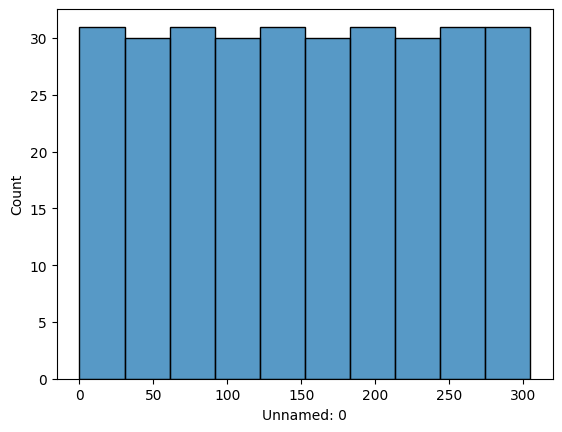

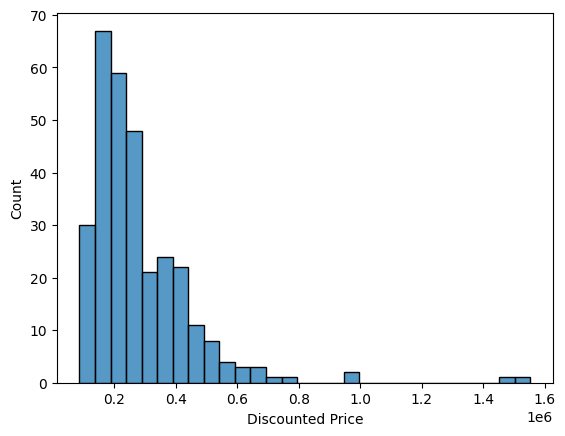

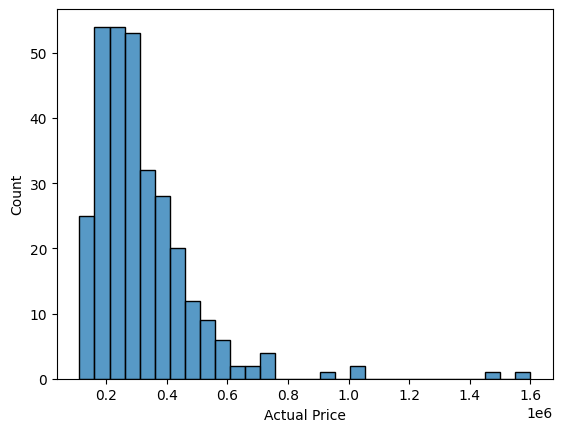

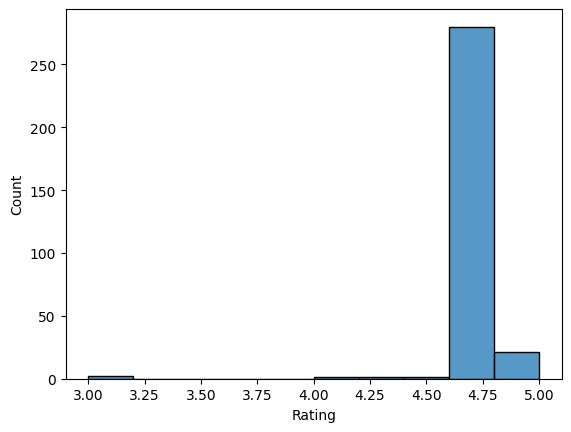

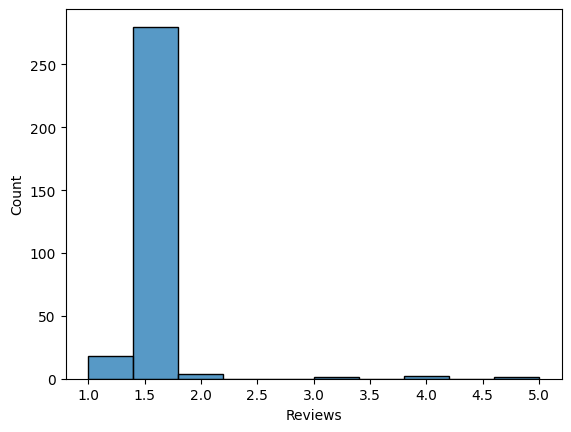

In [26]:
for i in data.select_dtypes(include='number').columns:
    sns.histplot(data=data,x=data[i])
    plt.show()

# Boxplot for checking outliers

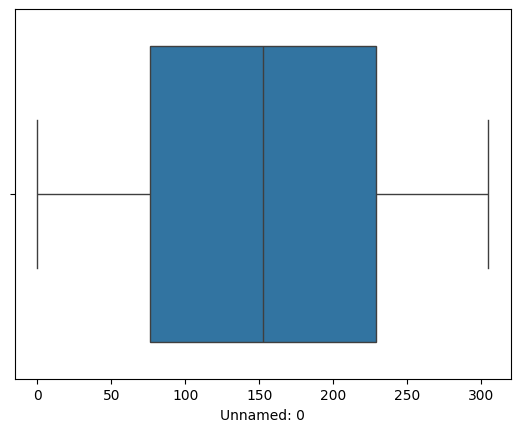

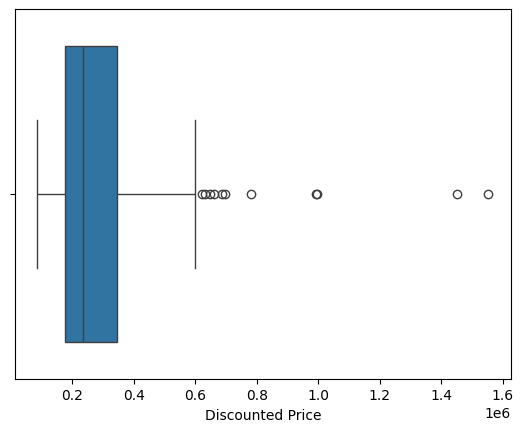

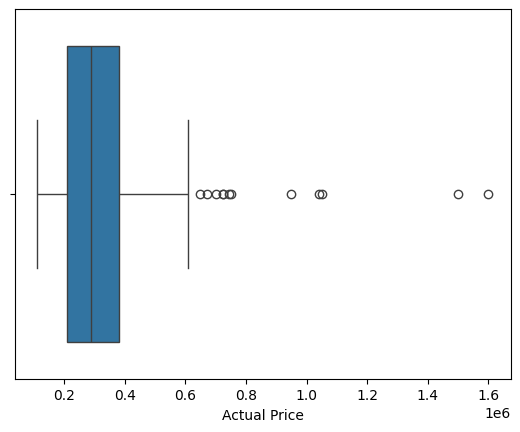

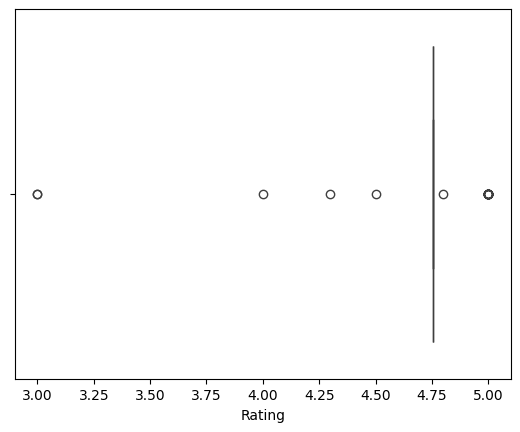

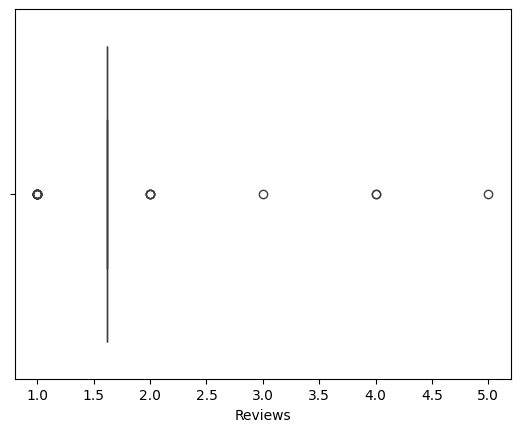

In [27]:
for i in data.select_dtypes(include='number').columns:
    sns.boxplot(data=data,x=data[i])
    plt.show()

# Scatterplot for seeing relationship

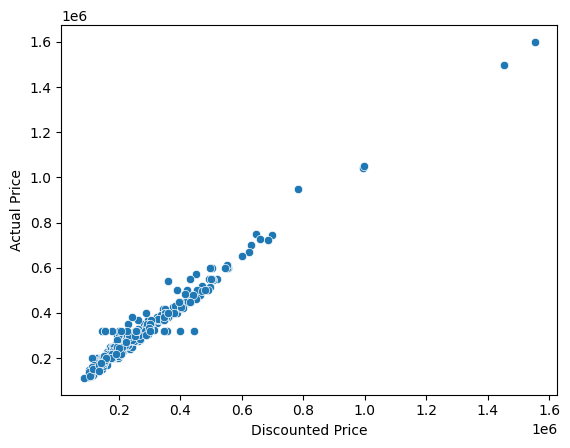

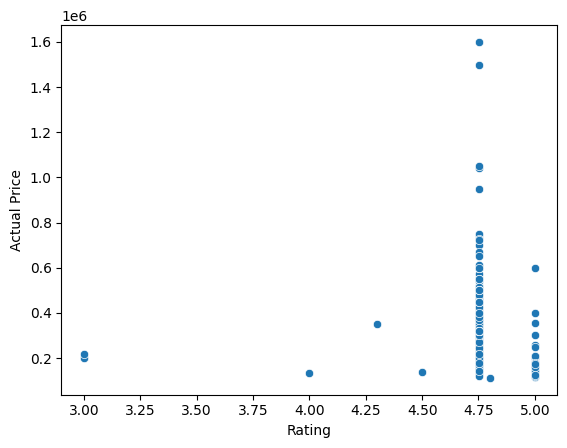

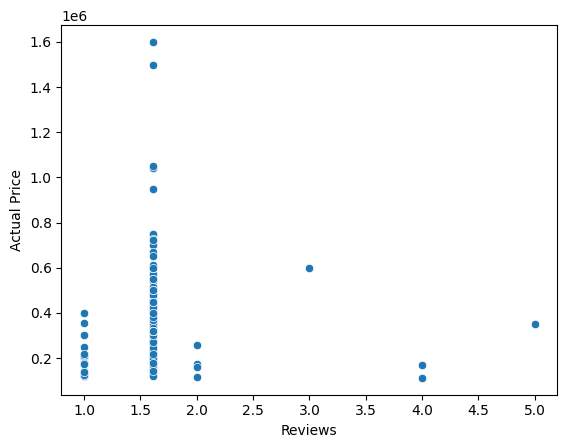

In [29]:
for i in ['Discounted Price','Rating','Reviews']:
    sns.scatterplot(data=data,x=i,y='Actual Price')
    plt.show()

In [30]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,306.0,152.500000,88.478811,0.0,76.250000,152.500000,228.750000,305.0
Discounted Price,306.0,277587.892157,170802.048112,85999.0,174249.000000,234499.000000,344999.750000,1552999.0
Actual Price,306.0,321261.587629,175771.300698,111999.0,209999.250000,289499.000000,379999.750000,1599900.0
Rating,306.0,4.753846,0.164013,3.0,4.753846,4.753846,4.753846,5.0
Reviews,306.0,1.615385,0.324688,1.0,1.615385,1.615385,1.615385,5.0


# Heatmap for checking correlation

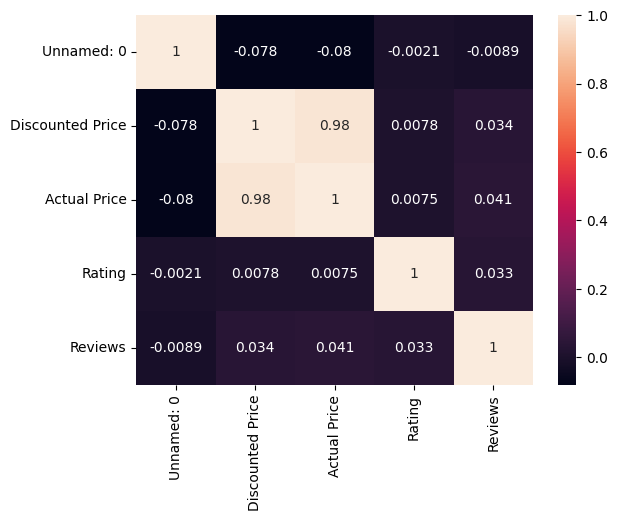

In [31]:
s=data.select_dtypes(include='number').corr()
sns.heatmap(s,annot=True)
plt.show()

# Fixing outliers

In [32]:
def whisker(col):
    q1,q3=np.percentile(col,[25,75])
    iqr=q3-q1
    lw=q1-1.5*iqr
    uw=q3+1.5*iqr
    return lw,uw

In [33]:
lw,uw=whisker(data['Discounted Price'])
data['Discounted Price']=np.where(data['Discounted Price']<lw,lw,data['Discounted Price'])
data['Discounted Price']=np.where(data['Discounted Price']>uw,uw,data['Discounted Price'])

# Checking Outliers

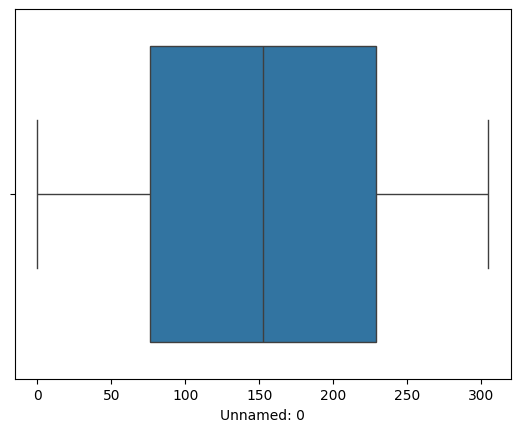

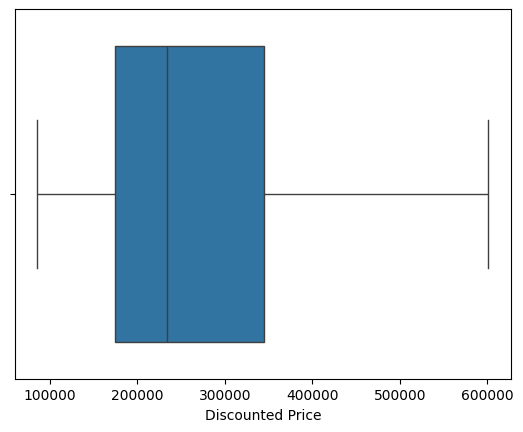

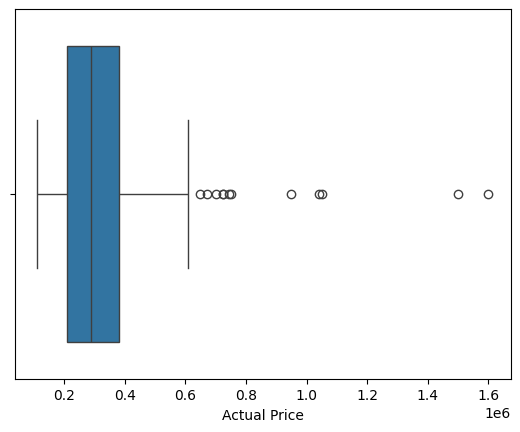

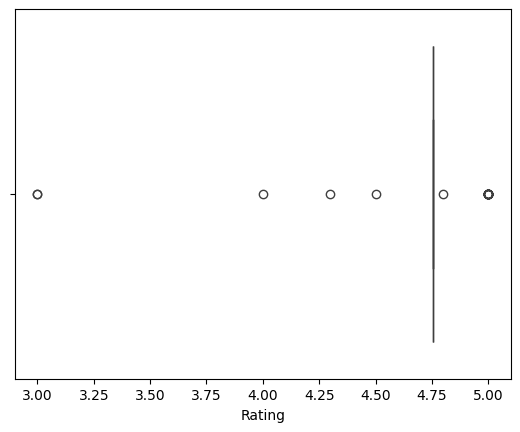

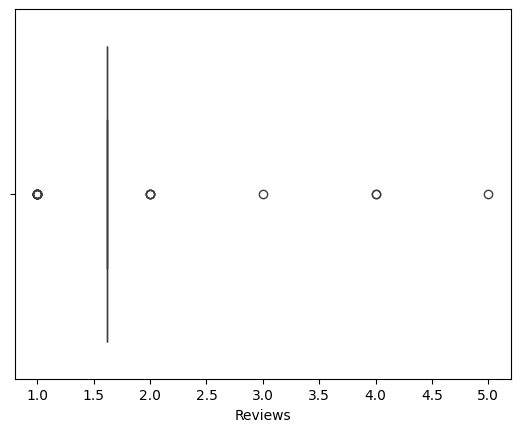

In [34]:
for i in data.select_dtypes(include='number').columns:
    sns.boxplot(data=data,x=data[i])
    plt.show()

# Labelling and Scalling for ML

In [35]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [36]:
data.head(2)

,Unnamed: 0,Name,Discounted Price,Actual Price,Rating,Reviews,Brand,Model
0,0.0,Apple MacBook Air 13 M1 MGN63 (8GB-256GB),203499.0,258000.0,5.0,2.0,Apple,MacBook Air 13 M1 MGN63
1,1.0,Apple Macbook Air 13 MW123 M4 Chip,281999.0,350000.0,4.3,5.0,Apple,Macbook Air 13 MW123 M4 Chip


# Labelling

In [37]:
name_en=LabelEncoder()
data['Name']=name_en.fit_transform(data['Name'])

In [38]:
Brand_en=LabelEncoder()
data['Brand']=Brand_en.fit_transform(data['Brand'])

In [39]:
Model_en=LabelEncoder()
data['Model']=Model_en.fit_transform(data['Model'])

In [40]:
data.head()

,Unnamed: 0,Name,Discounted Price,Actual Price,Rating,Reviews,Brand,Model
0,0.0,44,203499.0,258000.0,5.000000,2.000000,3,132
1,1.0,57,281999.0,350000.0,4.300000,5.000000,3,144
2,2.0,29,285999.0,330000.0,4.753846,1.615385,1,299
3,3.0,278,287999.0,340000.0,4.753846,1.615385,10,249
4,4.0,234,146999.0,175000.0,4.753846,1.615385,10,77


# Scalling

In [41]:
ss=StandardScaler()
new_data=pd.DataFrame(ss.fit_transform(data))

# Final New Data For ML Model

In [42]:
new_data

,0,1,2,3,4,5,6,7
0,-1.726400,-1.228291,-0.507270,-0.360498,1.503274e+00,1.186509e+00,-1.253601,-0.223249
1,-1.715079,-1.081122,0.115482,0.163767,-2.771662e+00,1.044128e+01,-1.253601,-0.085842
2,-1.703758,-1.398101,0.147214,0.049796,-5.424152e-15,6.849904e-16,-1.949793,1.688997
3,-1.692438,1.420742,0.163081,0.106781,-5.424152e-15,6.849904e-16,1.183072,1.116468
4,-1.681117,0.922633,-0.955492,-0.833476,-5.424152e-15,6.849904e-16,1.183072,-0.853030
...,...,...,...,...,...,...,...,...
301,1.681117,-1.477345,0.615277,0.000000,-5.424152e-15,6.849904e-16,-1.949793,0.795852
302,1.692438,0.662258,1.392717,0.000000,-5.424152e-15,6.849904e-16,0.486879,-0.967536
303,1.703758,-1.601873,-0.495362,0.000000,-5.424152e-15,6.849904e-16,-1.949793,-0.990437
304,1.715079,-1.499987,-0.098705,0.000000,-5.424152e-15,6.849904e-16,-1.949793,0.772951
